# K-means Housing

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

import seaborn as sns
import matplotlib.pyplot as plt


In [17]:
df = pd.read_csv('/workspaces/IgnacioSabinoG-IntroML/data/raw/housing.csv')
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


## Separado de las columnas de interés

In [18]:
df_interes = df[['Latitude', 'Longitude', 'MedInc']]
df_interes


,Latitude,Longitude,MedInc
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462
...,...,...,...
20635,39.48,-121.09,1.5603
20636,39.49,-121.21,2.5568
20637,39.43,-121.22,1.7000
20638,39.43,-121.32,1.8672


## División de la muestra

In [19]:

X_train, X_test = train_test_split(df_interes, test_size=0.2, random_state=42)

# Escalar los datos (Muy importante para K-means)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Entrenamiento del modelo

In [20]:
model = KMeans(n_clusters=6, random_state=42)
model.fit(X_train_scaled)

# Añadir la columna 'cluster' al DataFrame original de train
X_train['cluster'] = model.labels_

# Convertir a categoría (como pide el ejercicio)
X_train['cluster'] = X_train['cluster'].astype('category')

## Visualización

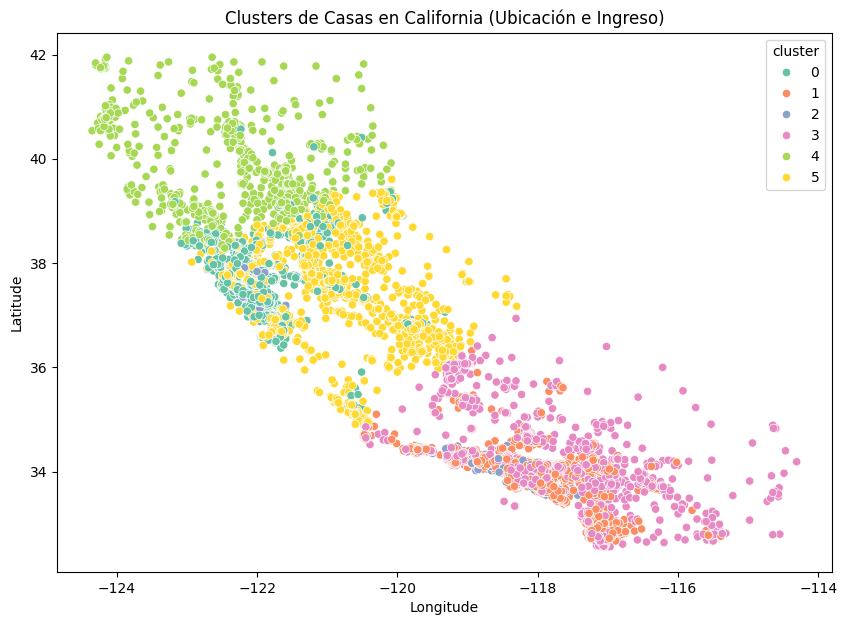

In [21]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=X_train, x='Longitude', y='Latitude', hue='cluster', palette='Set2')
plt.title('Clusters de Casas en California (Ubicación e Ingreso)')
plt.show()

Se puede discriminar rápido la distribución geográfica de California según las regiones sur (3), centro (5) y norte (4).

En la zona sur se pueden diferenciar a su vez, dos zonas de diferentes ingresos (1 y 2), en la zona central se difencia otra zona de ingresos diferentes (0) y algunas zonas asignadas también a la 2. Por último está la zona norte (4), donde hay zonas contíguas a la zona central donde se observan puntos asignados al grupo 0.

Ingreso medio por cada clúster:
  cluster     MedInc
2       2  10.305096
0       0   5.370513
1       1   5.225473
5       5   2.816021
3       3   2.720662
4       4   2.406233


/tmp/ipykernel_1489/1245333212.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ingreso_por_cluster, x='cluster', y='MedInc', palette='Set2')


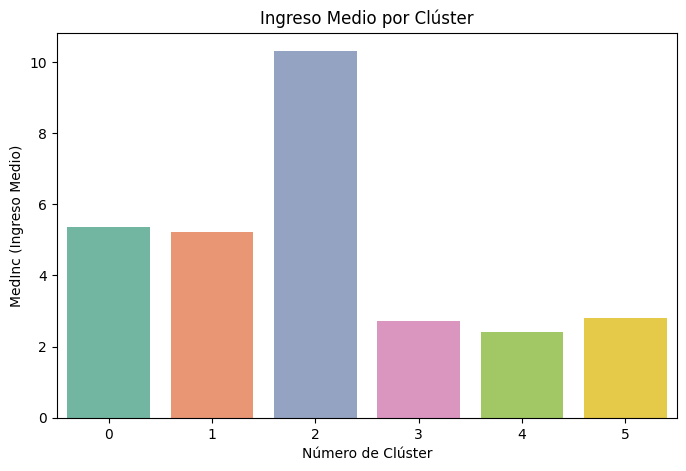

In [22]:
ingreso_por_cluster = X_train.groupby('cluster')['MedInc'].mean().reset_index()

# Ordenar de mayor a menor ingreso (opcional, pero ayuda a leerlo)
ingreso_por_cluster = ingreso_por_cluster.sort_values(by='MedInc', ascending=False)

print("Ingreso medio por cada clúster:")
print(ingreso_por_cluster)

# 2. Visualización opcional para comparar los grupos
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.barplot(data=ingreso_por_cluster, x='cluster', y='MedInc', palette='Set2')
plt.title('Ingreso Medio por Clúster')
plt.ylabel('MedInc (Ingreso Medio)')
plt.xlabel('Número de Clúster')
plt.show()

      cluster   cluster_nombre  MedInc
14196       3              Sur  3.2596
8267        3              Sur  3.8125
17445       1  Clase media Sur  4.1563
14265       3              Sur  1.9425
2271        5           Centro  3.5542


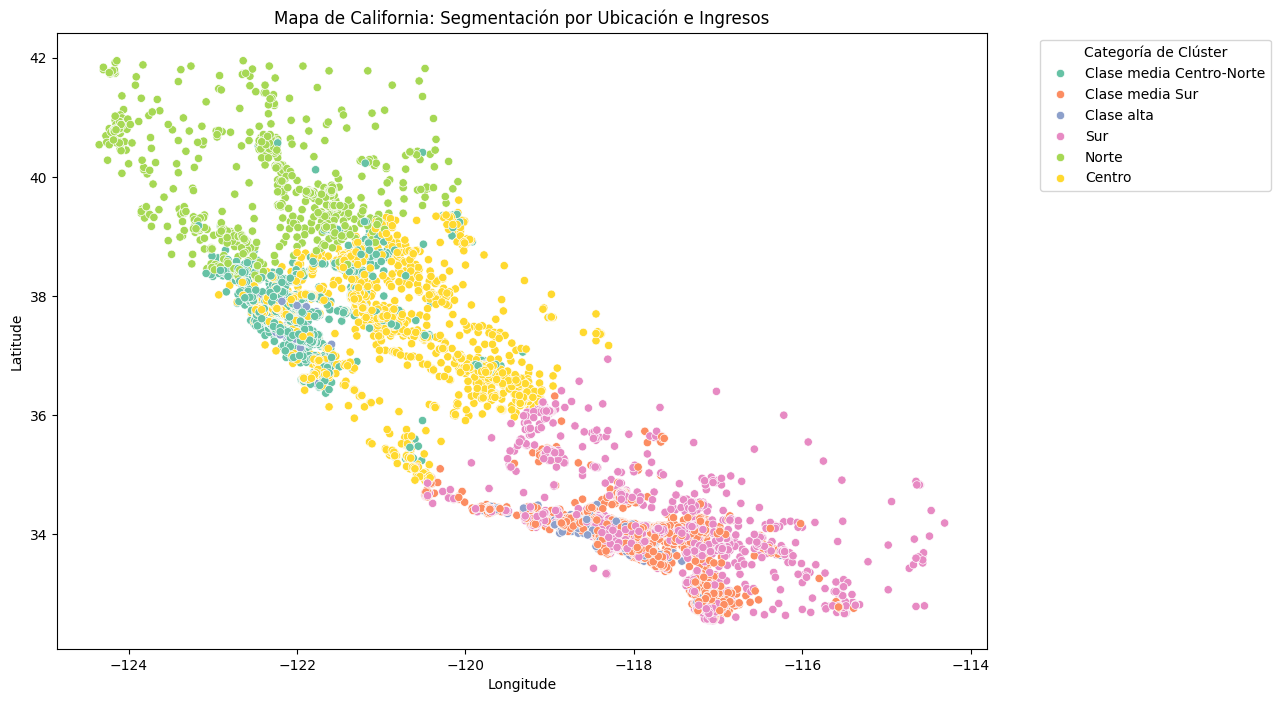

In [23]:
mapeo_nombres = {
    0: "Clase media Centro-Norte",
    1: "Clase media Sur",
    2: "Clase alta",
    3: "Sur",
    4: "Norte",
    5: "Centro"
}

# 2. Crear la nueva columna con los nombres
# Si 'cluster' es de tipo categórico, .map() funcionará perfectamente
X_train['cluster_nombre'] = X_train['cluster'].map(mapeo_nombres)

# 3. Verificar el resultado
print(X_train[['cluster', 'cluster_nombre', 'MedInc']].head())

# 4. (Opcional) Graficar con los nuevos nombres en la leyenda
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.scatterplot(data=X_train, x='Longitude', y='Latitude', hue='cluster_nombre', palette='Set2')
plt.title('Mapa de California: Segmentación por Ubicación e Ingresos')
plt.legend(title='Categoría de Clúster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Predicción

In [ ]:
X_test['cluster'] = model.predict(X_test_scaled)

X_test['cluster_nombre'] = X_test['cluster'].map(mapeo_nombres)

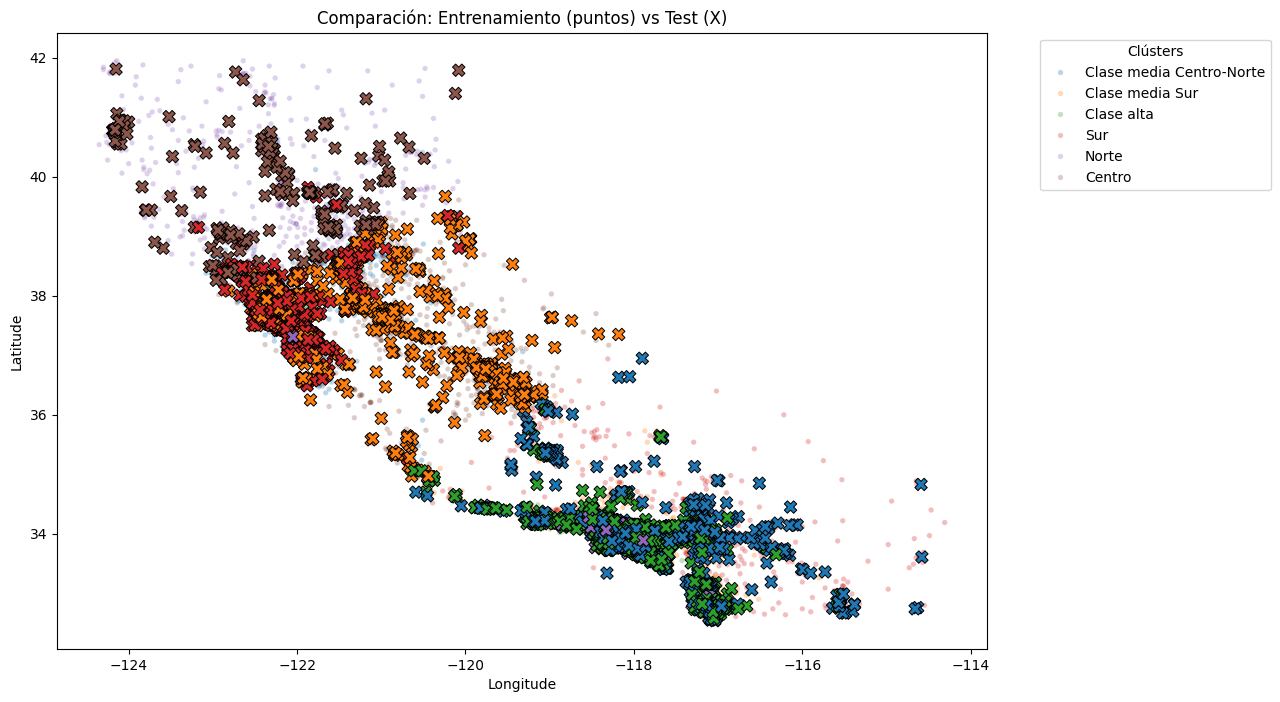

In [25]:
plt.figure(figsize=(12, 8))

# 1. Dibujamos el entrenamiento (fondo)
sns.scatterplot(data=X_train, x='Longitude', y='Latitude', hue='cluster_nombre', 
                palette='tab10', alpha=0.3, s=15, legend=True)

# 2. Dibujamos el test encima (quitamos el parámetro label para evitar el TypeError)
sns.scatterplot(data=X_test, x='Longitude', y='Latitude', hue='cluster_nombre', 
                palette='tab10', marker='X', s=80, edgecolor='black', legend=False)

plt.title('Comparación: Entrenamiento (puntos) vs Test (X)')
plt.legend(title='Clústers', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Modelo de Clasificación supervisada

Vamos a usar el Randon Forest como modelo de clasificación supervisada y luego probaremos con un decision tree

Precisión del modelo (Accuracy): 0.99
------------------------------
Informe de Clasificación:
                          precision    recall  f1-score   support

Clase media Centro-Norte       0.99      1.00      0.99       557
         Clase media Sur       1.00      1.00      1.00       897
              Clase alta       1.00      0.97      0.99       116
                     Sur       1.00      1.00      1.00      1397
                   Norte       0.98      0.99      0.99       246
                  Centro       0.99      0.99      0.99       915

                accuracy                           0.99      4128
               macro avg       0.99      0.99      0.99      4128
            weighted avg       0.99      0.99      0.99      4128



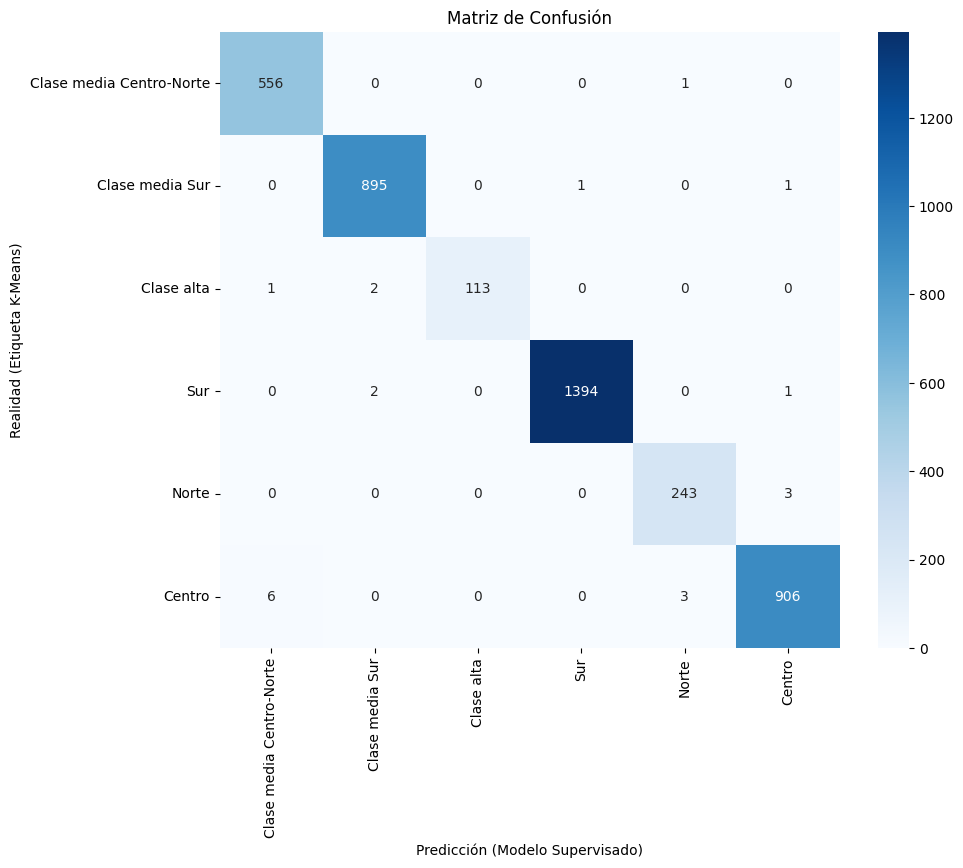

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_train = X_train['cluster']
y_test = X_test['cluster']

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

# --- EVALUACIÓN ---

# A. Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo (Accuracy): {accuracy:.2f}")
print("-" * 30)

# B. Classification Report (Precisión, Recall, F1-score por cada grupo)
print("Informe de Clasificación:")
print(classification_report(y_test, y_pred, target_names=mapeo_nombres.values()))

# C. Confusion Matrix (Visualizada con un mapa de calor)
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=mapeo_nombres.values(), 
            yticklabels=mapeo_nombres.values())
plt.title('Matriz de Confusión')
plt.xlabel('Predicción (Modelo Supervisado)')
plt.ylabel('Realidad (Etiqueta K-Means)')
plt.show()

Accuracy: Es casi perfecto, 0.99, ya que el modelo supervisado solo está intentando replicar la lógica geométrica del K-Means.
Matriz de Confusión: Muestra la altísima predicción, solo hay algunos datos que . Si hay números grandes fuera de la diagonal, significa que el modelo supervisado confunde, por ejemplo, el clúster "Sur" con "Clase media Sur".
Classification Report: Fíjate en el F1-score. Si algún clúster tiene un valor bajo, es posible que ese grupo sea muy pequeño o que sus fronteras con otros grupos no estén claras.

Probaremos con Decision Tree

In [27]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Entrenar el Árbol de Decisión
tree_clf = DecisionTreeClassifier(random_state=42, max_depth=5) # max_depth para que sea legible
tree_clf.fit(X_train_scaled, y_train)

# 2. Predicciones y Métricas
y_pred_tree = tree_clf.predict(X_test_scaled)

print("--- Evaluación Árbol de Decisión ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred_tree, target_names=mapeo_nombres.values()))

--- Evaluación Árbol de Decisión ---
Accuracy: 0.9755

Informe de Clasificación:
                          precision    recall  f1-score   support

Clase media Centro-Norte       0.95      0.98      0.96       557
         Clase media Sur       0.99      0.99      0.99       897
              Clase alta       0.98      0.96      0.97       116
                     Sur       0.99      1.00      1.00      1397
                   Norte       0.98      0.84      0.90       246
                  Centro       0.95      0.96      0.95       915

                accuracy                           0.98      4128
               macro avg       0.97      0.95      0.96      4128
            weighted avg       0.98      0.98      0.98      4128



También es muy alta la predicción, el accuracy baja a 0.98 y en algunas categorías el f1-score baja a 0.90.

Esto demuestra la superioridad del Random Forest frente al Decision Tree.

## Guardado de los modelos

In [29]:
import joblib

# 1. Guardar el escalador
joblib.dump(scaler, 'scaler_california.joblib')

# 2. Guardar el modelo K-Means
joblib.dump(model, 'kmeans_model_6_clusters.joblib')

# 3. Guardar el modelo de Clasificación (Árbol de Decisión)
joblib.dump(tree_clf, 'decision_tree_classifier.joblib')

print("Modelos guardados con éxito")

Modelos guardados con éxito
